The implementation of **MAPPO (Multi-Agent PPO)** algorithm.

Article Name: **The Surprising Effectiveness of PPO in Multi-Agent Games**

link: https://arxiv.org/abs/2103.01955

In [7]:
# DEPENDENCIES INSTALLATION & Environment Setup
import os
import sys
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

print("Setting up Multi-Agent RL Environment (PettingZoo) in Google Colab...")

!apt-get update -y -qq
!apt-get install -y -qq swig xvfb ffmpeg > /dev/null 2>&1

!pip install -q pyvirtualdisplay
!pip install -q torch numpy matplotlib imageio pytest pyyaml
!pip install -q pettingzoo mpe2

from pyvirtualdisplay import Display
display = Display(visible=0, size=(1400, 900))
display.start()

import numpy as np
import torch as T

PROJECT_DIR = "/content/MAPPO-Engine-Benchmark"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print(f"Working Directory set to: {os.getcwd()}")

folders = [
    "configs",
    "src",
    "src/agents",
    "src/networks",
    "src/wrappers",
    "tests",
    "logs",
    "videos"
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

Setting up Multi-Agent RL Environment (PettingZoo) in Google Colab...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 73.6 MB/s eta 0:00:00
Working Directory set to: /content/MAPPO-Engine-Benchmark


In [8]:
# WRITING MODULAR CODEBASE (CTDE MAPPO Architecture)

# --- File 1: src/networks/mappo_networks.py ---
%%writefile src/networks/mappo_networks.py
import torch as T
import torch.nn as nn
import numpy as np
from torch.distributions.categorical import Categorical
from torch.distributions.normal import Normal

def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer

class DecentralizedActor(nn.Module):
    """
    Decentralized Actor: Receives local observations (obs_dim) and generates action distribution.
    """
    def __init__(self, local_obs_dim, action_dim, is_continuous=False):
        super(DecentralizedActor, self).__init__()
        self.is_continuous = is_continuous

        self.network = nn.Sequential(
            layer_init(nn.Linear(local_obs_dim, 256)),
            nn.Tanh(),
            layer_init(nn.Linear(256, 256)),
            nn.Tanh()
        )

        if self.is_continuous:
            self.mu_head = layer_init(nn.Linear(256, action_dim), std=0.01)
            self.log_std = nn.Parameter(T.zeros(1, action_dim))
        else:
            self.action_head = layer_init(nn.Linear(256, action_dim), std=0.01)

    def forward(self, local_obs):
        features = self.network(local_obs)
        if self.is_continuous:
            mu = self.mu_head(features)
            action_std = self.log_std.squeeze(0).exp().expand_as(mu)
            return Normal(mu, action_std)
        else:
            logits = self.action_head(features)
            return Categorical(logits=logits)

class CentralizedCritic(nn.Module):
    """
    Centralized Critic (CTDE): Receives Global State / Concatenated Observations (state_dim)
    and estimates the centralized state-value V(S).
    """
    def __init__(self, global_state_dim):
        super(CentralizedCritic, self).__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(global_state_dim, 256)),
            nn.Tanh(),
            layer_init(nn.Linear(256, 256)),
            nn.Tanh(),
            layer_init(nn.Linear(256, 1), std=1.0)
        )

    def forward(self, global_state):
        return self.critic(global_state)

Overwriting src/networks/mappo_networks.py


In [9]:
# --- File 2: src/agents/mappo.py ---
%%writefile src/agents/mappo.py
import os
import numpy as np
import torch as T
import torch.nn as nn
import torch.optim as optim
from src.networks.mappo_networks import DecentralizedActor, CentralizedCritic

class MAPPOAgent:
    """
    Multi-Agent PPO (MAPPO) with Centralized Training & Decentralized Execution (CTDE).
    Supports Parameter Sharing across homogeneous agents.
    """
    def __init__(
        self,
        num_agents,
        local_obs_dim,
        global_state_dim,
        action_dim,
        gamma=0.99,
        alpha=3e-4,
        gae_lambda=0.95,
        policy_clip=0.2,
        dual_clip=3.0,
        batch_size=128,
        n_epochs=10,
        entropy_coef=0.01,
        vf_coef=0.5,
        max_grad_norm=0.5,
        is_continuous=False,
        chkpt_dir='tmp/mappo'
    ):
        self.num_agents = num_agents
        self.local_obs_dim = local_obs_dim
        self.global_state_dim = global_state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.alpha = alpha
        self.gae_lambda = gae_lambda
        self.policy_clip = policy_clip
        self.dual_clip = dual_clip
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.entropy_coef = entropy_coef
        self.vf_coef = vf_coef
        self.max_grad_norm = max_grad_norm
        self.is_continuous = is_continuous
        self.chkpt_dir = chkpt_dir

        os.makedirs(self.chkpt_dir, exist_ok=True)
        self.device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')

        # Parameter-Shared Actor and Centralized Critic
        self.actor = DecentralizedActor(local_obs_dim, action_dim, is_continuous).to(self.device)
        self.critic = CentralizedCritic(global_state_dim).to(self.device)

        self.optimizer = optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()),
            lr=alpha,
            eps=1e-5
        )

    def choose_actions(self, local_obs_dict, global_state):
        """
        Executes Decentralized Action Selection while querying Centralized Value.
        """
        actions = {}
        log_probs = {}

        # Convert local observations to tensors
        obs_tensor = T.tensor(np.array(list(local_obs_dict.values())), dtype=T.float32).to(self.device)
        state_tensor = T.tensor(global_state, dtype=T.float32).to(self.device)

        with T.no_grad():
            dist = self.actor(obs_tensor)
            value = self.critic(state_tensor)
            action_samples = dist.sample()
            log_prob_samples = dist.log_prob(action_samples)

            if self.is_continuous:
                log_prob_samples = log_prob_samples.sum(axis=-1)

        agent_keys = list(local_obs_dict.keys())
        for idx, key in enumerate(agent_keys):
            actions[key] = action_samples[idx].cpu().numpy()
            log_probs[key] = log_prob_samples[idx].cpu().numpy()

        return actions, log_probs, value.squeeze(-1).cpu().numpy()

    def get_value(self, global_state):
        state_tensor = T.tensor(global_state, dtype=T.float32).to(self.device)
        with T.no_grad():
            value = self.critic(state_tensor).squeeze(-1)
        return value.cpu().numpy()

    def learn(self, memory_data, next_global_state):
        obs_b, state_b, actions_b, log_probs_b, rewards_b, dones_b, values_b = memory_data
        n_steps = len(rewards_b)

        # Centralized Advantage Estimation (GAE)
        advantages = np.zeros_like(rewards_b, dtype=np.float32)
        next_value = self.get_value(next_global_state)
        last_gae_lam = 0.0

        for t in reversed(range(n_steps)):
            if t == n_steps - 1:
                next_non_terminal = 1.0 - float(dones_b[t])
                next_values = next_value
            else:
                next_non_terminal = 1.0 - float(dones_b[t])
                next_values = values_b[t + 1]

            delta = rewards_b[t] + self.gamma * next_values * next_non_terminal - values_b[t]
            advantages[t] = last_gae_lam = delta + self.gamma * self.gae_lambda * next_non_terminal * last_gae_lam

        returns_b = advantages + values_b

        # Flatten Step & Agent dimensions for Training
        b_obs = T.tensor(obs_b.reshape(-1, self.local_obs_dim), dtype=T.float32).to(self.device)
        b_states = T.tensor(np.repeat(state_b, self.num_agents, axis=0), dtype=T.float32).to(self.device)
        b_actions = T.tensor(actions_b.reshape(-1), dtype=T.int64 if not self.is_continuous else T.float32).to(self.device)
        b_log_probs = T.tensor(log_probs_b.reshape(-1), dtype=T.float32).to(self.device)

        # Repeat advantages/returns per agent for parameter-shared update
        b_advantages = T.tensor(np.repeat(advantages, self.num_agents), dtype=T.float32).to(self.device)
        b_returns = T.tensor(np.repeat(returns_b, self.num_agents), dtype=T.float32).to(self.device)
        b_values = T.tensor(np.repeat(values_b, self.num_agents), dtype=T.float32).to(self.device)

        batch_size = b_obs.shape[0]
        indices = np.arange(batch_size)

        for epoch in range(self.n_epochs):
            np.random.shuffle(indices)
            for start in range(0, batch_size, self.batch_size):
                end = start + self.batch_size
                mb_idx = indices[start:end]

                mb_obs = b_obs[mb_idx]
                mb_states = b_states[mb_idx]
                mb_actions = b_actions[mb_idx]
                mb_old_log_probs = b_log_probs[mb_idx]
                mb_advantages = b_advantages[mb_idx]
                mb_returns = b_returns[mb_idx]
                mb_values = b_values[mb_idx]

                mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)

                dist = self.actor(mb_obs)
                new_value = self.critic(mb_states).squeeze(-1)

                new_log_probs = dist.log_prob(mb_actions)
                if self.is_continuous:
                    new_log_probs = new_log_probs.sum(axis=-1)

                log_ratio = new_log_probs - mb_old_log_probs
                ratio = log_ratio.exp()

                # PPO Clipped Loss with Dual-Clip
                pg_loss1 = -mb_advantages * ratio
                pg_loss2 = -mb_advantages * T.clamp(ratio, 1 - self.policy_clip, 1 + self.policy_clip)

                if self.dual_clip is not None:
                    pg_loss_dual = T.max(pg_loss1, -mb_advantages * self.dual_clip)
                    pg_loss = T.where(mb_advantages < 0, pg_loss_dual, T.max(pg_loss1, pg_loss2)).mean()
                else:
                    pg_loss = T.max(pg_loss1, pg_loss2).mean()

                # Critic Loss with Value Clipping
                v_loss_unclipped = (new_value - mb_returns) ** 2
                v_clipped = mb_values + T.clamp(new_value - mb_values, -self.policy_clip, self.policy_clip)
                v_loss_clipped = (v_clipped - mb_returns) ** 2
                critic_loss = 0.5 * T.max(v_loss_unclipped, v_loss_clipped).mean()

                entropy_loss = dist.entropy().mean()
                total_loss = pg_loss + self.vf_coef * critic_loss - self.entropy_coef * entropy_loss

                self.optimizer.zero_grad()
                total_loss.backward()
                nn.utils.clip_grad_norm_(list(self.actor.parameters()) + list(self.critic.parameters()), self.max_grad_norm)
                self.optimizer.step()

Overwriting src/agents/mappo.py


In [10]:
# --- File 3: tests/test_mappo_shapes.py ---
%%writefile tests/test_mappo_shapes.py
import pytest
import numpy as np
from src.agents.mappo import MAPPOAgent

def test_mappo_ctde_forward_pass():
    """Validates CTDE Tensor dimensions and multi-agent forward updates."""
    num_agents = 3
    local_obs_dim = 8
    global_state_dim = num_agents * local_obs_dim
    action_dim = 5

    agent = MAPPOAgent(num_agents, local_obs_dim, global_state_dim, action_dim)

    # Dummy Multi-Agent Data
    obs_dict = {f"agent_{i}": np.random.randn(local_obs_dim).astype(np.float32) for i in range(num_agents)}
    global_state = np.random.randn(global_state_dim).astype(np.float32)

    actions, log_probs, value = agent.choose_actions(obs_dict, global_state)

    assert len(actions) == num_agents
    assert len(log_probs) == num_agents
    assert isinstance(value, (float, np.float32, np.ndarray))

# RUNNING AUTOMATED UNIT TESTS
print("\n---> Running PyTest Unit Tests for CTDE MAPPO Engine <---")
!pytest tests/


Overwriting tests/test_mappo_shapes.py


In [11]:
# MULTI-AGENT TRAINING ENGINE & EVALUATION (PettingZoo Simple Spread)
import imageio
import matplotlib.pyplot as plt
from mpe2 import simple_spread_v3
from src.agents.mappo import MAPPOAgent

def train_mappo_mpe(total_episodes=200, rollout_steps=128):
    env = simple_spread_v3.env(N=3, local_ratio=0.5, max_cycles=25, continuous_actions=False)
    env.reset()

    num_agents = len(env.possible_agents)
    local_obs_dim = env.observation_space(env.possible_agents[0]).shape[0]
    global_state_dim = local_obs_dim * num_agents
    action_dim = env.action_space(env.possible_agents[0]).n

    agent = MAPPOAgent(
        num_agents=num_agents,
        local_obs_dim=local_obs_dim,
        global_state_dim=global_state_dim,
        action_dim=action_dim,
        chkpt_dir='tmp/mappo_simple_spread'
    )

    episode_rewards = []

    print(f"\n---> Starting MAPPO Training on PettingZoo Simple Spread ({num_agents} Cooperative Agents)")

    for ep in range(1, total_episodes + 1):
        env.reset()
        obs_buf, state_buf, actions_buf, log_probs_buf, rewards_buf, dones_buf, values_buf = [], [], [], [], [], [], []

        ep_reward = 0
        step_count = 0

        # Collect Environment Episode Step
        for agent_id in env.agent_iter():
            observation, reward, termination, truncation, _ = env.last()
            done = termination or truncation

            if done:
                env.step(None)
                continue

            # Store current frame state at start of agent cycle
            if agent_id == env.possible_agents[0]:
                current_obs = {}
                for a in env.possible_agents:
                    o, _, _, _, _ = env.observe(a), *env.last()[1:]
                    current_obs[a] = env.observe(a)

                global_state = np.concatenate(list(current_obs.values()))
                actions, log_probs, value = agent.choose_actions(current_obs, global_state)

                obs_buf.append(np.array(list(current_obs.values())))
                state_buf.append(global_state)
                actions_buf.append(np.array(list(actions.values())))
                log_probs_buf.append(np.array(list(log_probs.values())))
                values_buf.append(value)

            env.step(actions[agent_id])
            ep_reward += reward
            step_count += 1

            if agent_id == env.possible_agents[-1]:
                rewards_buf.append(reward)
                dones_buf.append(done)

            if len(rewards_buf) >= rollout_steps:
                break

        # Train MAPPO Agent via CTDE
        if len(rewards_buf) > 0:
            memory_data = (
                np.array(obs_buf),
                np.array(state_buf),
                np.array(actions_buf),
                np.array(log_probs_buf),
                np.array(rewards_buf),
                np.array(dones_buf),
                np.array(values_buf)
            )
            agent.learn(memory_data, global_state)

        episode_rewards.append(ep_reward)

        if ep % 20 == 0 or ep == 1:
            print(f"Episode {ep}/{total_episodes} | Total Team Reward: {ep_reward:.2f}")

    env.close()
    return episode_rewards, agent

# Execute Training Run
rewards_history, trained_mappo_agent = train_mappo_mpe(total_episodes=150)


---> Starting MAPPO Training on PettingZoo Simple Spread (3 Cooperative Agents)
Episode 1/150 | Total Team Reward: -63.12
Episode 20/150 | Total Team Reward: -66.92
Episode 40/150 | Total Team Reward: -90.13
Episode 60/150 | Total Team Reward: -86.13
Episode 80/150 | Total Team Reward: -179.29
Episode 100/150 | Total Team Reward: -116.66
Episode 120/150 | Total Team Reward: -155.01
Episode 140/150 | Total Team Reward: -141.32


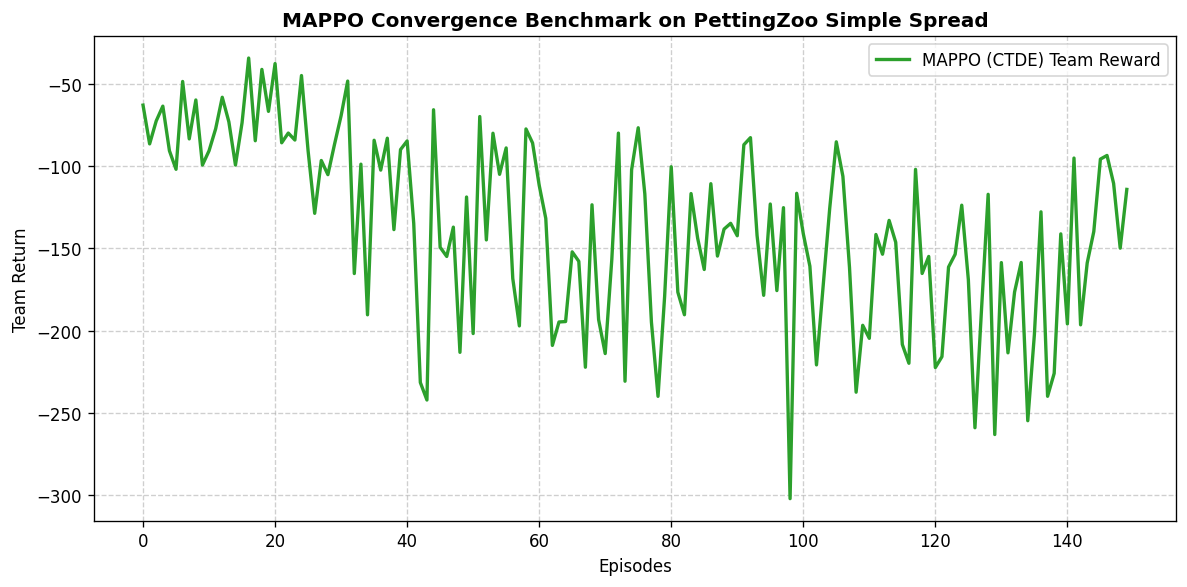


✓ MAPPO Project constructed successfully! Plots saved in logs/mappo_simple_spread_benchmark.png


In [12]:
# PLOTTING & LOGGING FOR GITHUB README
plt.figure(figsize=(10, 5), dpi=120)
plt.plot(rewards_history, label='MAPPO (CTDE) Team Reward', color='#2ca02c', linewidth=2)
plt.title('MAPPO Convergence Benchmark on PettingZoo Simple Spread', fontsize=12, fontweight='bold')
plt.xlabel('Episodes')
plt.ylabel('Team Return')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('logs/mappo_simple_spread_benchmark.png')
plt.show()

print("\n✓ MAPPO Project constructed successfully! Plots saved in logs/mappo_simple_spread_benchmark.png")
!zip -r /content/MAPPO-Engine-Benchmark.zip /content/MAPPO-Engine-Benchmark > /dev/null